# Gráficos de flujo T - Track


los grafico con python porque no se por qué los archivos eps no se actualizaron con la nueva informacion, y solo tengo los archivos .out

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import LogNorm

In [2]:
def leer_ttrack_2d(archivo):
    archivo = Path(archivo)
    texto = archivo.read_text(encoding="utf-8", errors="ignore")

    numero = (
        r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)"
        r"(?:[EeDd][-+]?\d+)?"
    )

    def extraer(patron, tipo=float):
        match = re.search(
            patron,
            texto,
            flags=re.MULTILINE | re.IGNORECASE
        )

        if not match:
            raise ValueError(f"No se encontró: {patron}")

        return tipo(match.group(1).replace("D", "E"))

    match_plano = re.search(
        r"^\s*axis\s*=\s*(xy|xz|yz)\b",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if not match_plano:
        raise ValueError(
            "No se encontró axis = xy, xz o yz."
        )

    plano = match_plano.group(1).lower()

    match_pagina = re.search(
        r"^\s*#?\s*newpage:\s*$",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    inicio_pagina = (
        match_pagina.end()
        if match_pagina
        else 0
    )

    pagina = texto[inicio_pagina:]

    match_hc = re.search(
        r"^\s*hc:.*$",
        pagina,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if not match_hc:
        raise ValueError(
            "No se encontró la línea hc de la matriz."
        )

    encabezado = pagina[:match_hc.start()]

    match_eje_horizontal = re.search(
        r"^\s*x:\s*([xyz])\s*\[cm\]",
        encabezado,
        flags=re.MULTILINE | re.IGNORECASE
    )

    match_eje_vertical = re.search(
        r"^\s*y:\s*([xyz])\s*\[cm\]",
        encabezado,
        flags=re.MULTILINE | re.IGNORECASE
    )

    if not match_eje_horizontal or not match_eje_vertical:
        raise ValueError(
            "No se pudieron identificar los ejes del gráfico."
        )

    eje_horizontal = match_eje_horizontal.group(1).lower()
    eje_vertical = match_eje_vertical.group(1).lower()

    n_horizontal = extraer(
        rf"^\s*n{eje_horizontal}\s*=\s*(\d+)",
        int
    )

    n_vertical = extraer(
        rf"^\s*n{eje_vertical}\s*=\s*(\d+)",
        int
    )

    match_rango_horizontal = re.search(
        rf"p:\s*xmin\(\s*({numero})\s*\)"
        rf"\s*xmax\(\s*({numero})\s*\)",
        encabezado,
        flags=re.IGNORECASE
    )

    match_rango_vertical = re.search(
        rf"p:\s*ymin\(\s*({numero})\s*\)"
        rf"\s*ymax\(\s*({numero})\s*\)",
        encabezado,
        flags=re.IGNORECASE
    )

    if match_rango_horizontal:
        minimo_horizontal = float(
            match_rango_horizontal.group(1).replace("D", "E")
        )

        maximo_horizontal = float(
            match_rango_horizontal.group(2).replace("D", "E")
        )

    else:
        minimo_horizontal = extraer(
            rf"^\s*{eje_horizontal}min\s*=\s*({numero})"
        )

        maximo_horizontal = extraer(
            rf"^\s*{eje_horizontal}max\s*=\s*({numero})"
        )

    if match_rango_vertical:
        minimo_vertical = float(
            match_rango_vertical.group(1).replace("D", "E")
        )

        maximo_vertical = float(
            match_rango_vertical.group(2).replace("D", "E")
        )

    else:
        minimo_vertical = extraer(
            rf"^\s*{eje_vertical}min\s*=\s*({numero})"
        )

        maximo_vertical = extraer(
            rf"^\s*{eje_vertical}max\s*=\s*({numero})"
        )

    match_limites = re.search(
        rf"set:\s*c3\[\s*({numero})\s*\]"
        rf"\s*c4\[\s*({numero})\s*\]",
        encabezado,
        flags=re.IGNORECASE
    )

    if match_limites:
        cmin = float(
            match_limites.group(1).replace("D", "E")
        )

        cmax = float(
            match_limites.group(2).replace("D", "E")
        )

    else:
        cmin = None
        cmax = None

    match_particula = re.search(
        r"^\s*part\s*=\s*([^\n#]+)",
        texto,
        flags=re.MULTILINE | re.IGNORECASE
    )

    particula = (
        match_particula.group(1).strip()
        if match_particula
        else archivo.stem
    )

    inicio_datos = inicio_pagina + match_hc.end()

    match_fin = re.search(
        r"^\s*#\s*gshow\s*$"
        r"|^\s*newpage:\s*$"
        r"|^\s*#\s*newpage:\s*$"
        r"|^\s*#\s*Information for Restart",
        texto[inicio_datos:],
        flags=re.MULTILINE | re.IGNORECASE
    )

    if match_fin:
        fin_datos = inicio_datos + match_fin.start()
    else:
        fin_datos = len(texto)

    bloque_datos = texto[inicio_datos:fin_datos]

    numeros = re.findall(
        numero,
        bloque_datos
    )

    valores = np.array([
        float(valor.replace("D", "E"))
        for valor in numeros
    ])

    cantidad = n_horizontal * n_vertical

    if valores.size < cantidad:
        raise ValueError(
            f"Se esperaban {cantidad} valores, "
            f"pero se encontraron {valores.size}."
        )

    flujo = valores[:cantidad].reshape(
        n_vertical,
        n_horizontal
    )

    positivos = flujo[flujo > 0]

    if positivos.size == 0:
        raise ValueError(
            "El archivo no contiene valores positivos."
        )

    if cmin is None or cmin <= 0:
        cmin = positivos.min()

    if cmax is None or cmax <= 0:
        cmax = positivos.max()

    if cmax <= cmin:
        cmin = positivos.min()
        cmax = positivos.max()

    geometria = []

    match_gshow = re.search(
        r"^\s*#\s*gshow\s*$",
        texto[inicio_datos:],
        flags=re.MULTILINE | re.IGNORECASE
    )

    if match_gshow:
        inicio_gshow = (
            inicio_datos + match_gshow.end()
        )

        bloque_gshow = texto[inicio_gshow:]

        match_colorbar = re.search(
            r"^\s*z:\s*xorg",
            bloque_gshow,
            flags=re.MULTILINE | re.IGNORECASE
        )

        if match_colorbar:
            bloque_gshow = bloque_gshow[
                :match_colorbar.start()
            ]

        lineas = bloque_gshow.splitlines()
        i = 0

        while i < len(lineas):
            if lineas[i].strip().lower() == "clip:":
                puntos = []
                i += 1

                while i < len(lineas):
                    partes = lineas[i].split()

                    if len(partes) != 2:
                        break

                    try:
                        coordenada_1 = float(
                            partes[0].replace("D", "E")
                        )

                        coordenada_2 = float(
                            partes[1].replace("D", "E")
                        )

                        puntos.append(
                            (coordenada_1, coordenada_2)
                        )

                        i += 1

                    except ValueError:
                        break

                if len(puntos) >= 2:
                    geometria.append(
                        np.array(puntos)
                    )

            else:
                i += 1

    return {
        "archivo": archivo,
        "flujo": flujo,
        "plano": plano,
        "eje_horizontal": eje_horizontal,
        "eje_vertical": eje_vertical,
        "minimo_horizontal": minimo_horizontal,
        "maximo_horizontal": maximo_horizontal,
        "minimo_vertical": minimo_vertical,
        "maximo_vertical": maximo_vertical,
        "cmin": cmin,
        "cmax": cmax,
        "particula": particula,
        "geometria": geometria
    }

def graficar_ttrack_2d(
    archivo,
    mostrar_geometria=True,
    mostrar_bineado=False,
    tamano=None,
    barra="abajo"
):
    datos = leer_ttrack_2d(archivo)

    es_error = datos["archivo"].stem.lower().endswith("_err")

    valores = np.ma.masked_less_equal(
        datos["flujo"],
        0
    )

    ancho_datos = (
        datos["maximo_horizontal"]
        - datos["minimo_horizontal"]
    )

    alto_datos = (
        datos["maximo_vertical"]
        - datos["minimo_vertical"]
    )

    proporcion = ancho_datos / alto_datos

    if tamano is None:
        if proporcion >= 2:
            tamano = (15, 5)
        elif proporcion <= 0.5:
            tamano = (6, 10)
        else:
            tamano = (8, 7)

    cmap = plt.colormaps["jet"].resampled(100).copy()
    cmap.set_bad("white")
    cmap.set_under("white")

    fig, ax = plt.subplots(
        figsize=tamano,
        constrained_layout=True
    )

    imagen = ax.imshow(
        valores,
        origin="upper",
        extent=[
            datos["minimo_horizontal"],
            datos["maximo_horizontal"],
            datos["minimo_vertical"],
            datos["maximo_vertical"]
        ],
        aspect="equal",
        interpolation="nearest",
        cmap=cmap,
        norm=LogNorm(
            vmin=datos["cmin"],
            vmax=datos["cmax"]
        )
    )

    if mostrar_geometria:
        for curva in datos["geometria"]:
            ax.plot(
                curva[:, 0],
                curva[:, 1],
                color="black",
                linewidth=0.7
            )

    if mostrar_bineado:
        n_vertical, n_horizontal = datos["flujo"].shape

        texto_bineado = (
            f"n{datos['eje_horizontal']} = {n_horizontal}\n"
            f"n{datos['eje_vertical']} = {n_vertical}"
        )

        ax.text(
            0.02,
            0.97,
            texto_bineado,
            transform=ax.transAxes,
            horizontalalignment="left",
            verticalalignment="top",
            bbox={
                "facecolor": "white",
                "edgecolor": "black",
                "alpha": 0.8,
                "boxstyle": "round,pad=0.3"
            }
        )

    if barra == "abajo":
        colorbar = fig.colorbar(
            imagen,
            ax=ax,
            orientation="horizontal",
            pad=0.16,
            fraction=0.10,
            aspect=45
        )

    elif barra == "derecha":
        colorbar = fig.colorbar(
            imagen,
            ax=ax,
            orientation="vertical",
            pad=0.03,
            fraction=0.05,
            aspect=30
        )

    else:
        raise ValueError(
            'barra debe ser "abajo" o "derecha".'
        )

    if es_error:
        colorbar.set_label("Error relativo")
        tipo = "Error relativo del T-Track"
    else:
        colorbar.set_label("Flujo [1/cm²/source]")
        tipo = "T-Track"

    ax.set_xlabel(
        f"{datos['eje_horizontal']} [cm]"
    )

    ax.set_ylabel(
        f"{datos['eje_vertical']} [cm]"
    )

    ax.set_title(
        f"{tipo} de {datos['particula']} "
        f"en el plano {datos['plano']}\n"
        f"{datos['archivo'].name}",
        pad=10
    )

    ax.set_xlim(
        datos["minimo_horizontal"],
        datos["maximo_horizontal"]
    )

    ax.set_ylim(
        datos["minimo_vertical"],
        datos["maximo_vertical"]
    )

    plt.show()

In [10]:
from pathlib import Path
carpeta_out = Path("../out")
track_xy = carpeta_out / "track_xy.out"
track_xy_err = carpeta_out / "track_xy_err.out"
track_yz = carpeta_out / "track_yz.out"
track_yz_err = carpeta_out / "track_yz_err.out"

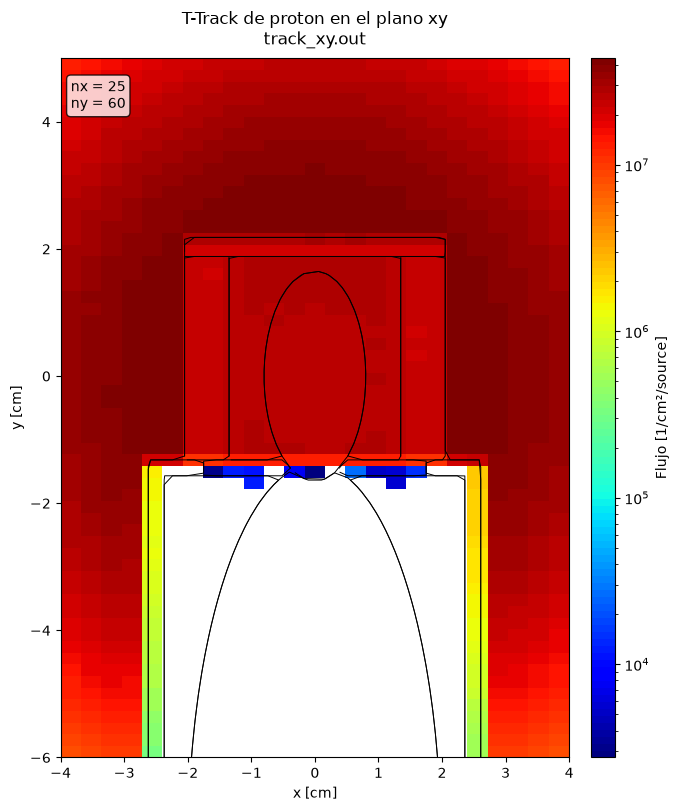

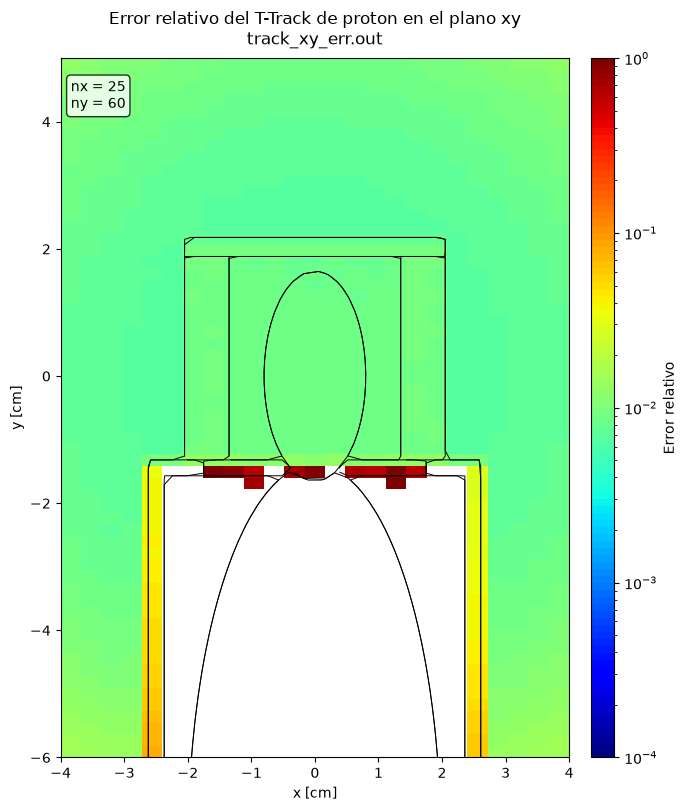

In [11]:
graficar_ttrack_2d(
    track_xy,
    tamano=(7, 8),
    mostrar_bineado=True,
    barra="derecha"
)
graficar_ttrack_2d(
    track_xy_err,
    tamano=(7, 8),
    mostrar_bineado=True,
    barra="derecha"
) 

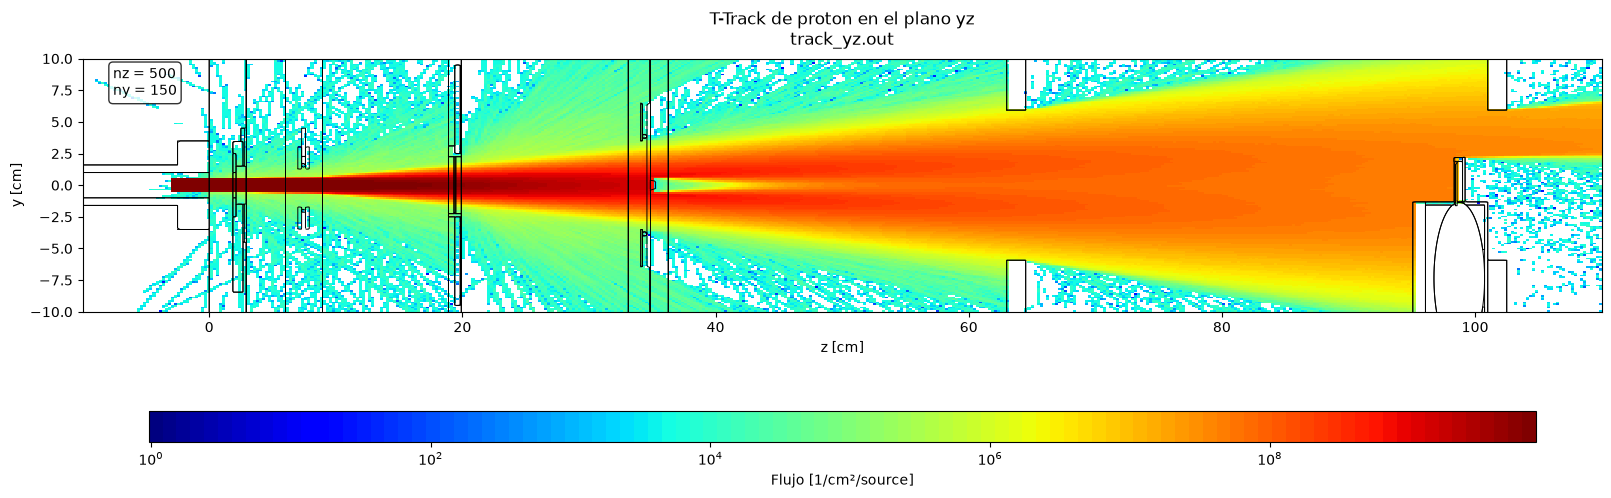

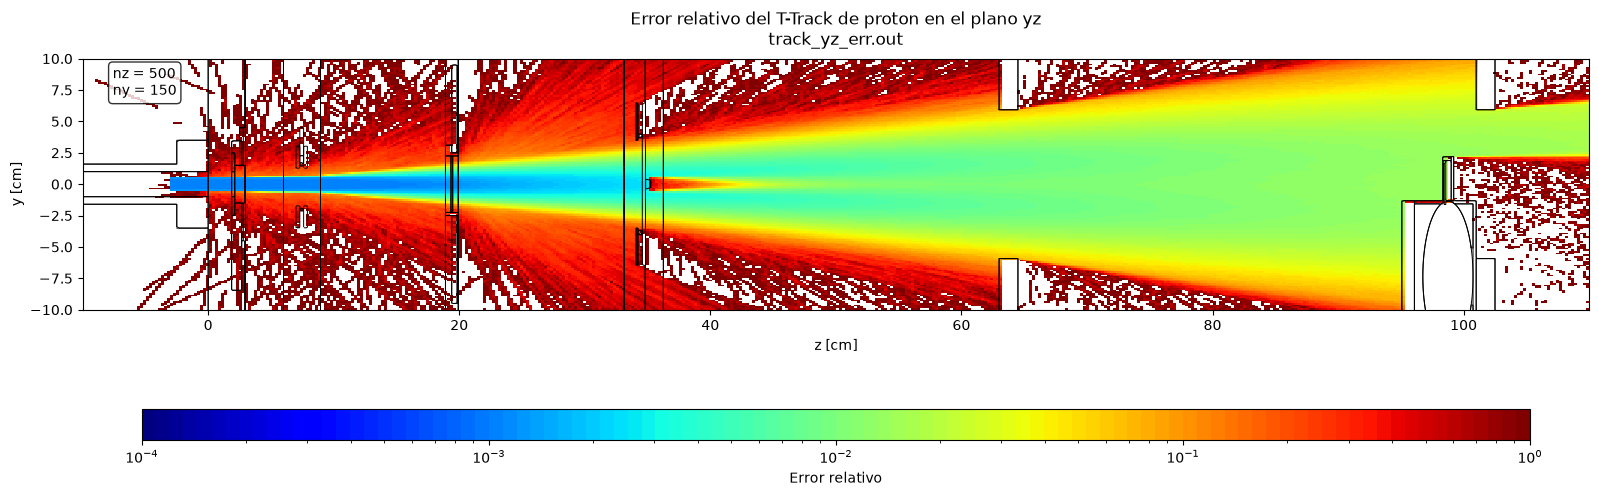

In [12]:
graficar_ttrack_2d(
    track_yz,
    tamano=(16, 5),
    mostrar_bineado=True,
    barra="abajo"
)
graficar_ttrack_2d(
    track_yz_err,
    mostrar_bineado=True,
    tamano=(16, 5),
    barra="abajo"
)